# Regularized Models Notebook

**Week 4-5** stuff:
- multiple target audio features
- `Dummy`, `Linear`, `Ridge`, and `Lasso` techniques

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 100)
np.random.seed(42)


In [2]:
SRC_PATH = Path.cwd() / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from project_utils import compute_regression_metrics, ensure_dir, ensure_processed_data


In [3]:
data_parts = ensure_processed_data(data_dir="data", processed_dir="data/processed", random_state=42)
train_df = data_parts["train"]
val_df = data_parts["val"]
test_df = data_parts["test"]

print("Train/Val/Test shapes:", train_df.shape, val_df.shape, test_df.shape)


Train/Val/Test shapes: (91259, 14) (19556, 14) (19556, 14)


In [4]:
proposal_targets = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "loudness",
    "tempo",
]

available_targets = [t for t in proposal_targets if t in train_df.columns]
if not available_targets:
    raise ValueError("No proposal targets found in the processed dataset.")

available_targets


['danceability', 'energy', 'valence', 'acousticness', 'loudness', 'tempo']

In [5]:
def build_models():
    return {
        "mean_baseline": DummyRegressor(strategy="mean"),
        "linear_regression": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("linearregression", LinearRegression()),
            ]
        ),
        "ridge": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 30), cv=5)),
            ]
        ),
        "lasso": Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "lasso",
                    LassoCV(
                        alphas=np.logspace(-4, 1, 40),
                        cv=5,
                        max_iter=20000,
                        random_state=42,
                    ),
                ),
            ]
        ),
    }

rows = []
param_rows = []

for target in available_targets:
    feature_cols = [c for c in train_df.columns if c != target]

    X_train, y_train = train_df[feature_cols], train_df[target]
    X_val, y_val = val_df[feature_cols], val_df[target]
    X_test, y_test = test_df[feature_cols], test_df[target]

    for model_name, model in build_models().items():
        fitted = model.fit(X_train, y_train)

        for split_name, X_split, y_split in [
            ("validation", X_val, y_val),
            ("test", X_test, y_test),
        ]:
            y_pred = fitted.predict(X_split)
            metrics = compute_regression_metrics(y_split, y_pred)
            rows.append(
                {
                    "target": target,
                    "model": model_name,
                    "split": split_name,
                    **metrics,
                    "n_features": len(feature_cols),
                }
            )

        alpha = None
        if model_name == "ridge":
            alpha = fitted.named_steps["ridge"].alpha_
        elif model_name == "lasso":
            alpha = fitted.named_steps["lasso"].alpha_

        if alpha is not None:
            param_rows.append({"target": target, "model": model_name, "best_alpha": float(alpha)})

results_df = pd.DataFrame(rows)
params_df = pd.DataFrame(param_rows)

results_df.head()


,target,model,split,mse,mae,r2,n_features
0,danceability,mean_baseline,validation,0.035289,0.153125,-3.572663e-06,13
1,danceability,mean_baseline,test,0.035253,0.152924,-8.320265e-07,13
2,danceability,linear_regression,validation,0.020462,0.114973,4.201414e-01,13
3,danceability,linear_regression,test,0.020519,0.114989,4.179489e-01,13
4,danceability,ridge,validation,0.020462,0.114974,4.201438e-01,13


In [6]:
outputs_dir = ensure_dir("outputs")
results_path = outputs_dir / "regularized_results.csv"
params_path = outputs_dir / "regularized_best_params.csv"
test_results_path = outputs_dir / "regularized_test_results.csv"

results_df.to_csv(results_path, index=False)
params_df.to_csv(params_path, index=False)
results_df[results_df["split"] == "test"].to_csv(test_results_path, index=False)

print(f"Saved -> {results_path}")
print(f"Saved -> {params_path}")
print(f"Saved -> {test_results_path}")


Saved -> outputs/regularized_results.csv
Saved -> outputs/regularized_best_params.csv
Saved -> outputs/regularized_test_results.csv


In [7]:
test_results = results_df[results_df["split"] == "test"].copy()
r2_pivot = test_results.pivot(index="target", columns="model", values="r2")
r2_pivot


model,lasso,linear_regression,mean_baseline,ridge
target,,,,
acousticness,0.564997,0.565006,-4.717791e-06,0.565006
danceability,0.417972,0.417949,-8.320265e-07,0.417951
energy,0.735335,0.735330,-6.482152e-06,0.735331
loudness,0.721361,0.721361,-3.349301e-07,0.721362
tempo,0.068486,0.068463,-1.096647e-05,0.068461
valence,0.292469,0.292444,-8.285051e-05,0.292444


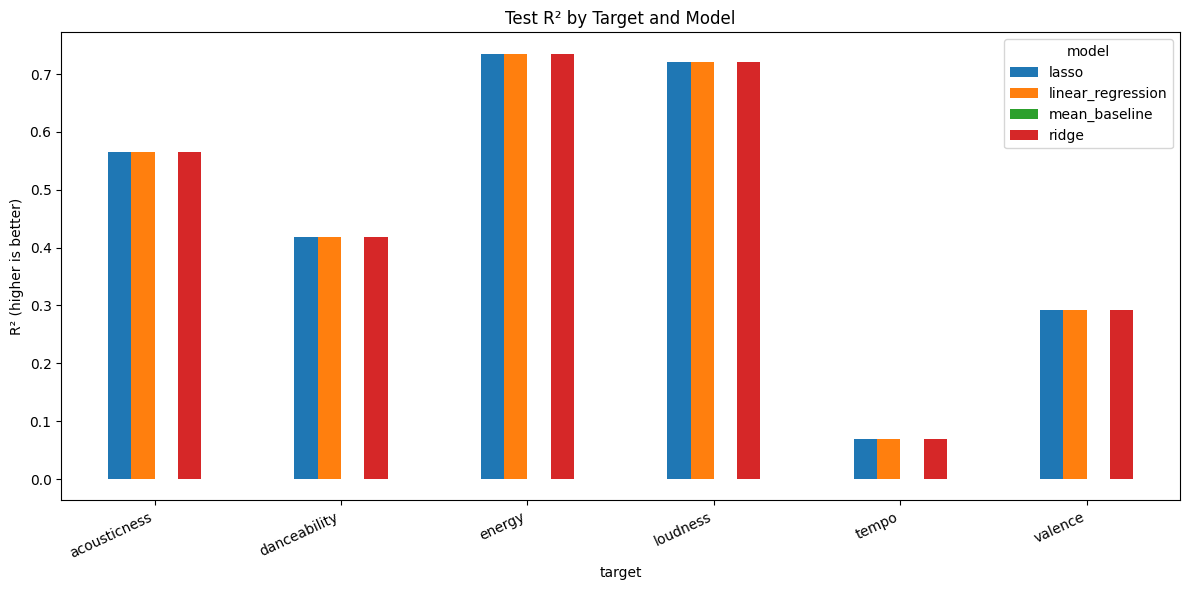

In [8]:
ax = r2_pivot.plot(kind="bar", figsize=(12, 6))
ax.set_ylabel("R² (higher is better)")
ax.set_title("Test R² by Target and Model")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


In [9]:
best_by_target = (
    test_results.sort_values("r2", ascending=False)
    .groupby("target", as_index=False)
    .first()
    .sort_values("r2", ascending=False)
)

best_path = outputs_dir / "best_model_by_target.csv"
best_by_target.to_csv(best_path, index=False)
print(f"Saved -> {best_path}")

best_by_target


Saved -> outputs/best_model_by_target.csv


,target,model,split,mse,mae,r2,n_features
2,energy,lasso,test,0.017964,0.103532,0.735335,13
3,loudness,ridge,test,11.838634,2.417420,0.721362,13
0,acousticness,ridge,test,0.052196,0.180446,0.565006,13
1,danceability,lasso,test,0.020518,0.115003,0.417972,13
5,valence,lasso,test,0.047415,0.177151,0.292469,13
4,tempo,lasso,test,827.878452,23.294725,0.068486,13


## Predicted vs Actual — Best Model per Target

One scatter plot per proposal target, using the best model (by test R²) from the table above.
The red dashed line is the ideal `y = x`. Closer to the line means better fit.

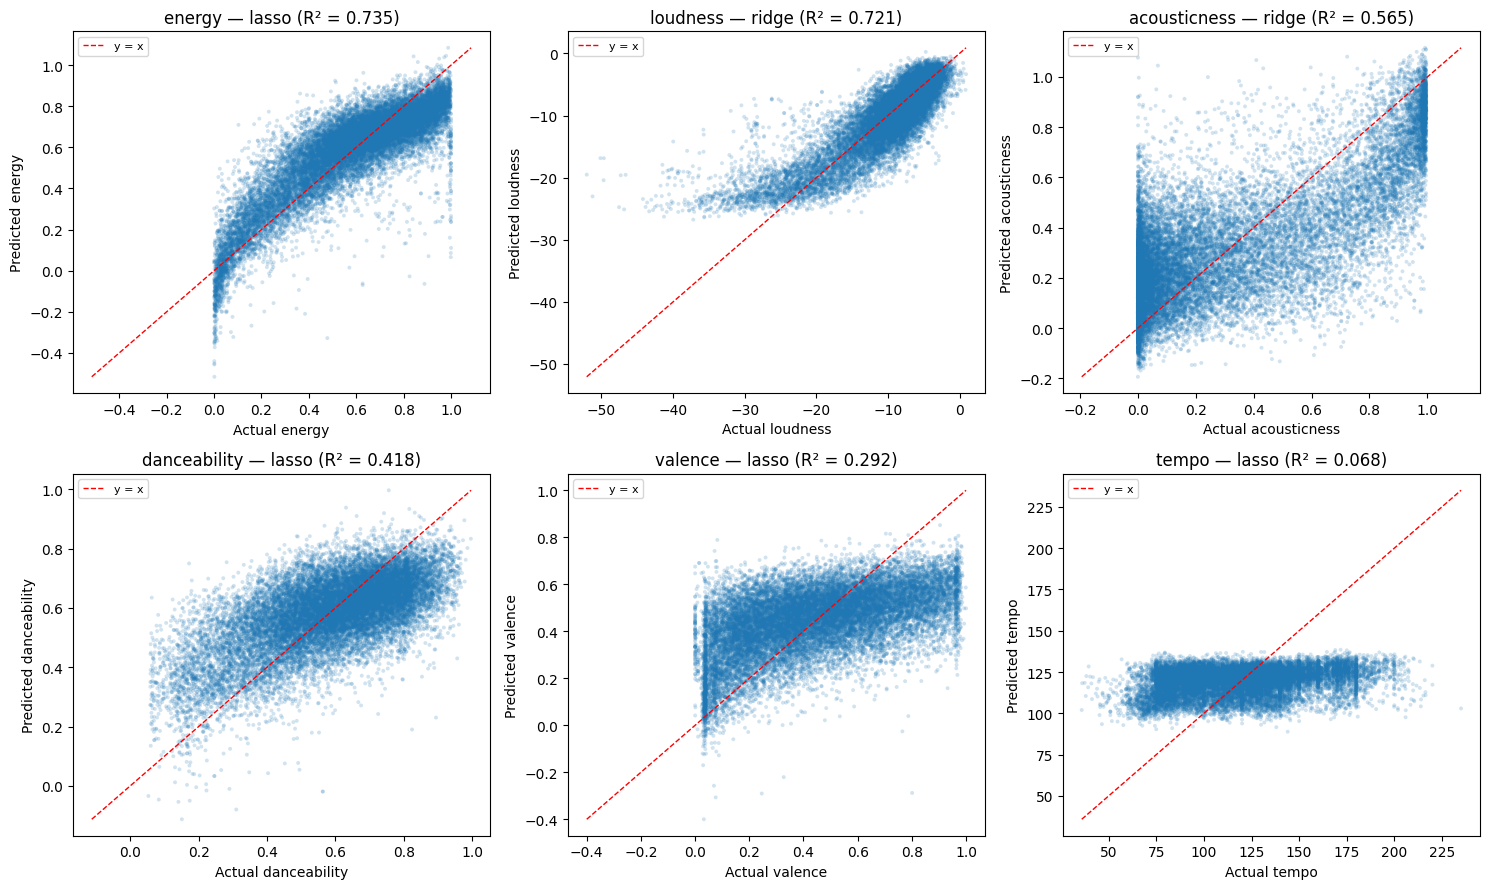

Saved -> outputs/scatter_predicted_vs_actual.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (_, row) in zip(axes, best_by_target.iterrows()):
    target = row["target"]
    model_name = row["model"]
    feature_cols = [c for c in train_df.columns if c != target]

    X_train, y_train = train_df[feature_cols], train_df[target]
    X_test, y_test = test_df[feature_cols], test_df[target]

    model = build_models()[model_name]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.2, s=8, edgecolors="none")
    lo = float(min(y_test.min(), y_pred.min()))
    hi = float(max(y_test.max(), y_pred.max()))
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
    ax.set_xlabel(f"Actual {target}")
    ax.set_ylabel(f"Predicted {target}")
    ax.set_title(f"{target} — {model_name} (R² = {row['r2']:.3f})")
    ax.legend(loc="best", fontsize=8)

plt.tight_layout()
scatter_path = outputs_dir / "scatter_predicted_vs_actual.png"
plt.savefig(scatter_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {scatter_path}")

## Lasso Coefficient / Feature Redundancy Analysis

Re-fit a Lasso pipeline per target and record the *standardized* coefficients (features were z-scored before fitting, so magnitudes are comparable across features). Coefficients that Lasso drives to exactly zero are features the model judged redundant for that target — this is the substantive "feature redundancy" finding the proposal asks about.

Outputs:
- `outputs/lasso_coefficients.csv` — raw coefficient table (rows: targets, cols: features)
- `outputs/lasso_sparsity_summary.csv` — count of zeroed features per target
- `outputs/lasso_coefficient_heatmap.png` — visual summary

In [11]:
lasso_coefs = {}
for target in available_targets:
    feature_cols = [c for c in train_df.columns if c != target]
    X_train, y_train = train_df[feature_cols], train_df[target]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(
            alphas=np.logspace(-4, 1, 40),
            cv=5,
            max_iter=20000,
            random_state=42,
        )),
    ])
    pipe.fit(X_train, y_train)
    coefs = pipe.named_steps["lasso"].coef_
    lasso_coefs[target] = pd.Series(coefs, index=feature_cols)

all_features = sorted({f for s in lasso_coefs.values() for f in s.index})
coef_df = pd.DataFrame(
    {t: s.reindex(all_features) for t, s in lasso_coefs.items()}
).T
coef_df.index.name = "target"

coef_path = outputs_dir / "lasso_coefficients.csv"
coef_df.to_csv(coef_path)
print(f"Saved -> {coef_path}")

ZERO_TOL = 1e-9
zero_counts = (coef_df.abs() < ZERO_TOL).sum(axis=1).rename("zeroed_features")
total_counts = coef_df.notna().sum(axis=1).rename("total_features")
sparsity_df = pd.concat([zero_counts, total_counts], axis=1)
sparsity_df["sparsity_ratio"] = sparsity_df["zeroed_features"] / sparsity_df["total_features"]
sparsity_path = outputs_dir / "lasso_sparsity_summary.csv"
sparsity_df.to_csv(sparsity_path)
print(f"Saved -> {sparsity_path}")
sparsity_df

Saved -> outputs/lasso_coefficients.csv
Saved -> outputs/lasso_sparsity_summary.csv


,zeroed_features,total_features,sparsity_ratio
target,,,
danceability,0,13,0.0
energy,0,13,0.0
valence,0,13,0.0
acousticness,0,13,0.0
loudness,0,13,0.0
tempo,0,13,0.0


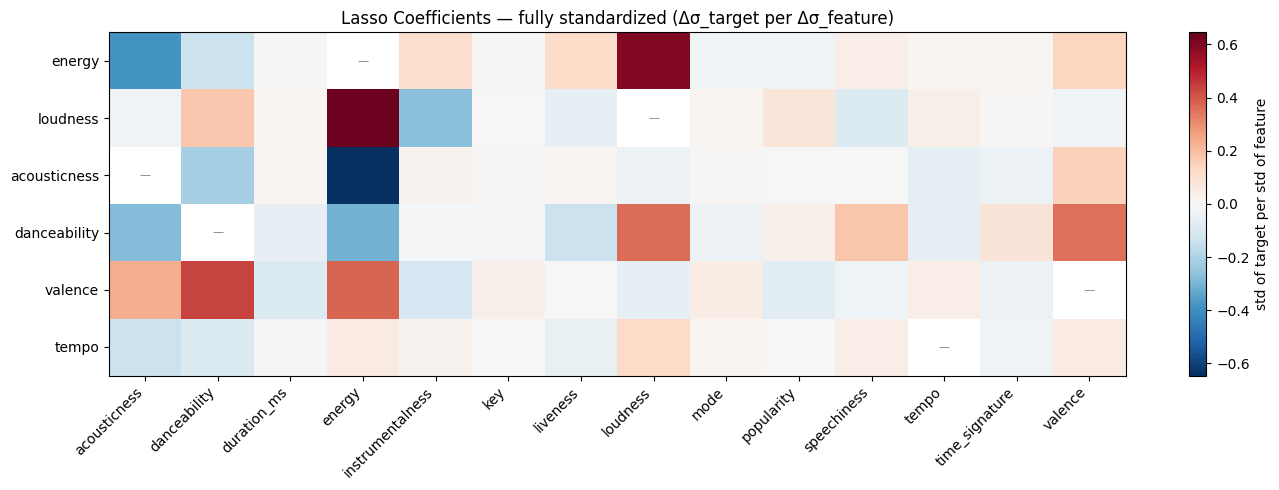

Saved -> outputs/lasso_coefficient_heatmap.png


In [12]:
# Rescale coefficients by target std so the heatmap is comparable across targets.
# (Same fits, same sparsity — just unit-normalized for visualization.)
target_order = best_by_target["target"].tolist()
y_stds = train_df[target_order].std()
plot_df = coef_df.loc[target_order].div(y_stds, axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
vmax = float(np.nanmax(np.abs(plot_df.values)))
im = ax.imshow(plot_df.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_df.index)
ax.set_title("Lasso Coefficients — fully standardized (Δσ_target per Δσ_feature)")

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        v = plot_df.values[i, j]
        if pd.isna(v):
            ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="gray")
        elif abs(v) < 1e-9:
            ax.text(j, i, "0", ha="center", va="center", fontsize=7, color="black")

plt.colorbar(im, ax=ax, label="std of target per std of feature")
plt.tight_layout()
heatmap_path = outputs_dir / "lasso_coefficient_heatmap.png"
plt.savefig(heatmap_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {heatmap_path}")

### Lasso Path — feature drop-off order

CV picked alphas small enough that no feature was zeroed at the optimum (see sparsity table above). To still extract the redundancy signal, sweep alpha upward and record the order in which Lasso drops features. Features dropped *first* are the most redundant for that target.

Saved -> outputs/lasso_feature_rank.csv


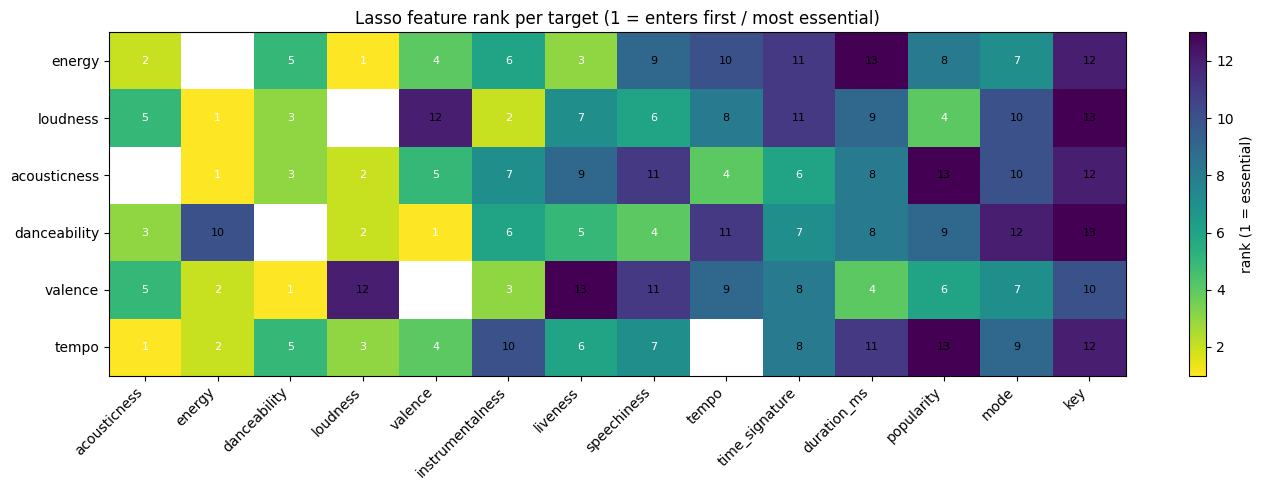

Saved -> outputs/lasso_feature_rank_heatmap.png


,acousticness,energy,danceability,loudness,valence,instrumentalness,liveness,speechiness,tempo,time_signature,duration_ms,popularity,mode,key
target,,,,,,,,,,,,,,
energy,2.0,NaN,5.0,1.0,4.0,6.0,3.0,9.0,10.0,11.0,13.0,8.0,7.0,12.0
loudness,5.0,1.0,3.0,NaN,12.0,2.0,7.0,6.0,8.0,11.0,9.0,4.0,10.0,13.0
acousticness,NaN,1.0,3.0,2.0,5.0,7.0,9.0,11.0,4.0,6.0,8.0,13.0,10.0,12.0
danceability,3.0,10.0,NaN,2.0,1.0,6.0,5.0,4.0,11.0,7.0,8.0,9.0,12.0,13.0
valence,5.0,2.0,1.0,12.0,NaN,3.0,13.0,11.0,9.0,8.0,4.0,6.0,7.0,10.0
tempo,1.0,2.0,5.0,3.0,4.0,10.0,6.0,7.0,NaN,8.0,11.0,13.0,9.0,12.0


In [13]:
from sklearn.linear_model import lasso_path

drop_order = {}
for target in available_targets:
    feature_cols = [c for c in train_df.columns if c != target]
    X = train_df[feature_cols].to_numpy()
    y = train_df[target].to_numpy()
    X_std = (X - X.mean(axis=0)) / X.std(axis=0)
    y_std = (y - y.mean()) / y.std()

    alphas, coefs, _ = lasso_path(X_std, y_std, n_alphas=80, eps=1e-3)
    # alphas are sorted high -> low. Record the alpha at which each feature first becomes nonzero.
    activation_alpha = {}
    for j, feat in enumerate(feature_cols):
        nonzero_steps = np.where(np.abs(coefs[j]) > 1e-9)[0]
        activation_alpha[feat] = float(alphas[nonzero_steps[0]]) if len(nonzero_steps) else 0.0
    # Higher activation alpha = feature is essential (survives heavy regularization).
    # Lower activation alpha = feature is redundant (only useful when penalty is light).
    ordered = sorted(activation_alpha.items(), key=lambda kv: -kv[1])
    drop_order[target] = ordered

# Display: rank of each feature per target, where rank 1 = most essential.
rank_df = pd.DataFrame(
    {t: {feat: r + 1 for r, (feat, _) in enumerate(ordered)} for t, ordered in drop_order.items()}
).T
rank_df.index.name = "target"
rank_df = rank_df.loc[target_order]
# Sort columns by mean rank so the most-essential features (across targets) appear on the left.
rank_df = rank_df.reindex(columns=rank_df.mean(axis=0).sort_values().index)

rank_path = outputs_dir / "lasso_feature_rank.csv"
rank_df.to_csv(rank_path)
print(f"Saved -> {rank_path}")

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(rank_df.values, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(rank_df.shape[1]))
ax.set_xticklabels(rank_df.columns, rotation=45, ha="right")
ax.set_yticks(range(rank_df.shape[0]))
ax.set_yticklabels(rank_df.index)
ax.set_title("Lasso feature rank per target (1 = enters first / most essential)")
for i in range(rank_df.shape[0]):
    for j in range(rank_df.shape[1]):
        v = rank_df.values[i, j]
        if not pd.isna(v):
            ax.text(j, i, int(v), ha="center", va="center", color="white" if v <= rank_df.shape[1] / 2 else "black", fontsize=8)
plt.colorbar(im, ax=ax, label="rank (1 = essential)")
plt.tight_layout()
rank_plot_path = outputs_dir / "lasso_feature_rank_heatmap.png"
plt.savefig(rank_plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {rank_plot_path}")
rank_df

## Next Notebook
Run [final.ipynb](final.ipynb) to produce the final comparison charts and submission summary.
